# Initial-condition Fisher information from the PSMAP

This notebook calculates how precisely a **complete state-resolved 2D image** can determine the eight Gaussian initial-cloud parameters

$$\theta=(\mu_{x0},\mu_{y0},\mu_{v_x0},\mu_{v_y0},\sigma_{x0},\sigma_{y0},\sigma_{v_x0},\sigma_{v_y0}).$$

Unlike the synthetic-shot pipeline, this calculation does not sample atoms. It deterministically integrates the single-atom PSMAP response against a Gaussian initial distribution. The resulting Cramer-Rao lower bound is an information-theoretic benchmark: no unbiased estimator using the same image can beat it.

## Model and analytic derivatives

At every PSMAP node $q=(x_0,y_0,v_{x0},v_{y0})$, ais++ supplies output-port amplitudes and phases. These define state probabilities $P_s(q,\phi_0)$. For Gaussian cloud parameters $\theta$, the expected probability in state $s$ and final-position bin $b$ is

$$p_{s,b}(\theta)=\int dq\;p(q\mid\theta)P_s(q,\phi_0)\,\mathbf{1}[x_f(q),y_f(q)\in b].$$

At each final-image location, the marginal Gaussian density is analytic and the initial velocities conditioned on that final position remain Gaussian. The remaining two-dimensional conditional integral is evaluated deterministically with Gauss-Hermite quadrature and linear interpolation of the PSMAP response. The derivative identity is

$$\partial_{\theta_j}p_{s,b}=\mathbb{E}_{q\sim p(q|\theta)}\!\left[P_s(q,\phi_0)\mathbf{1}_b\,\partial_{\theta_j}\log p(q|\theta)\right].$$

The notebook evaluates derivatives with stable central differences of the smooth deterministic image probabilities. For $N$ launched atoms, the multinomial Fisher matrix is

$$F_{ij}=N\sum_k\frac{1}{p_k}\frac{\partial p_k}{\partial\theta_i}\frac{\partial p_k}{\partial\theta_j},$$

where $k$ runs over all ground/excited image bins and the undetected category. The covariance bound is $F^{-1}$ when all parameter combinations are identifiable.

In [12]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path('..').resolve()
sys.path.insert(0, str(REPO))

from aispy.psmap import load_psmap
from helpers.psmap_fisher import PARAMETER_NAMES, PSMAPConditionalImageModel


## Configuration

`T_DET` must match the value supplied to `PSMAPSurrogate` when generating the dataset. The nominal cloud below matches the current synthetic-data configuration. `PARAMETER_SCALES` only improves numerical conditioning; it does not impose a prior.

In [13]:
PSMAP_PATH = REPO / 'output-files' / 'PSGRID4D_CONFOCAL_Z0.h5'
T_DET = 3.8
PHI0 = 0.
N_ATOMS = 100_000_000
HERMITE_ORDER = 12  # increase to 16 to check quadrature convergence

# Match the compact 2D-image artifacts: 64 bins over +/-5 mm.
N_BINS = 64
IMAGE_RANGE = 3e-3
x_edges = np.linspace(-IMAGE_RANGE, IMAGE_RANGE, N_BINS + 1)
y_edges = np.linspace(-IMAGE_RANGE, IMAGE_RANGE, N_BINS + 1)

# Order: mu_x0, mu_y0, mu_vx0, mu_vy0, sigma_x0, sigma_y0, sigma_vx0, sigma_vy0.
theta_nominal = np.array([0, 0, 0, 0, 100e-6, 100e-6, 309e-6/3, 309e-6/3], dtype=float)

# Typical shot-to-shot variation scales used only to condition the Fisher matrix.
parameter_scales = np.array([10e-6, 10e-6, 10e-6, 10e-6, 10e-6, 10e-6, 10e-6, 10e-6])
derivative_steps = parameter_scales * 1e-2

print(f'PSMAP: {PSMAP_PATH}')
print(f'Local evaluation phase: phi0 = {PHI0:.3f} rad; launched atoms = {N_ATOMS:,}')


PSMAP: /home/ndm33/aispp-sims/gaussian-wavefront-spatially-resolved-inference/output-files/PSGRID4D_CONFOCAL_Z0.h5
Local evaluation phase: phi0 = 0.000 rad; launched atoms = 100,000,000


## Build the deterministic image model

This interpolates the PSMAP response and integrates the conditional initial-velocity distribution at every final-image location using Gauss-Hermite quadrature.

In [14]:
psmap = load_psmap(PSMAP_PATH)
model = PSMAPConditionalImageModel.from_psmap(
    psmap, T_DET, PHI0, x_edges, y_edges, hermite_order=HERMITE_ORDER
)

probabilities, jacobian, detected_probability = model.probabilities_and_jacobian(
    theta_nominal, derivative_steps, observation_model="launched"
)
print(f"Gauss-Hermite order per velocity axis: {HERMITE_ORDER}")
print(f"Probability detected inside image ROI: {detected_probability:.6f}")
print(f"Probability normalization check: {probabilities.sum():.12f}")
print(f"Max derivative-sum error: {np.abs(jacobian.sum(axis=0)).max():.3e}")


Gauss-Hermite order per velocity axis: 12
Probability detected inside image ROI: 0.896204
Probability normalization check: 1.000000000000
Max derivative-sum error: 0.000e+00


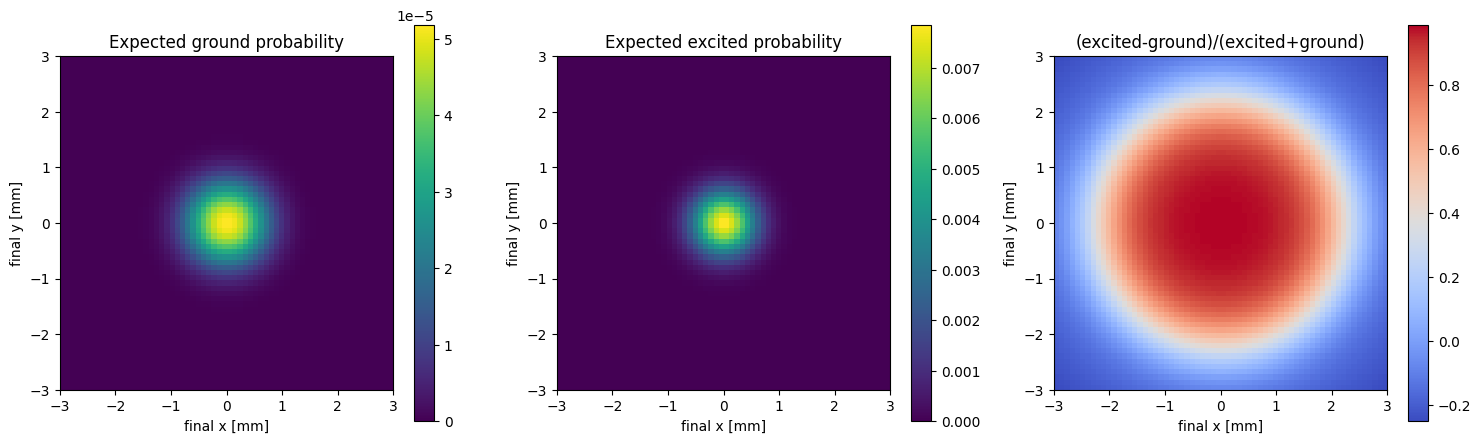

In [15]:
n_pixels = N_BINS * N_BINS
ground_image = probabilities[:n_pixels].reshape(N_BINS, N_BINS)
excited_image = probabilities[n_pixels:2*n_pixels].reshape(N_BINS, N_BINS)
extent = np.array([-IMAGE_RANGE, IMAGE_RANGE, -IMAGE_RANGE, IMAGE_RANGE]) * 1e3

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, image, title in zip(
    axs[:2], [ground_image, excited_image], ['Expected ground probability', 'Expected excited probability']
):
    im = ax.imshow(image.T, origin='lower', extent=extent, aspect='equal')
    ax.set_title(title)
    ax.set_xlabel('final x [mm]')
    ax.set_ylabel('final y [mm]')
    fig.colorbar(im, ax=ax)

contrast = np.divide(excited_image - ground_image, excited_image + ground_image,
                     out=np.zeros_like(ground_image), where=(excited_image + ground_image) > 0)
im = axs[2].imshow(contrast.T, origin='lower', extent=extent, cmap='coolwarm', aspect='equal',)# vmin=-1, vmax=1)
axs[2].set_title('(excited-ground)/(excited+ground)')
axs[2].set_xlabel('final x [mm]')
axs[2].set_ylabel('final y [mm]')
fig.colorbar(im, ax=axs[2])
fig.tight_layout()


## Full-image Fisher information and precision bound

The `launched` model uses the state-resolved image plus the number of undetected/out-of-ROI atoms, assuming the launched atom count is known. The `detected_conditional` model fixes the detected count and discards all information carried by detection efficiency. The latter is the more conservative comparison when only normalized detected images are used.

The synthetic training data draws a random common interferometer phase per shot, so the known-phase CRLB is optimistic for the regression notebooks. The next cell adds `phi0` as an explicit nuisance parameter and reports the Schur-complement bound for the eight cloud parameters after marginalizing over that unknown phase.


In [16]:
launched_result = model.fisher_information(
    theta_nominal, N_ATOMS, parameter_scales, observation_model='launched'
)
conditional_result = model.fisher_information(
    theta_nominal, N_ATOMS * detected_probability, parameter_scales,
    observation_model='detected_conditional'
)

display_scales = np.array([1e6, 1e6, 1e6, 1e6, 1e6, 1e6, 1e6, 1e6])
units = ['um', 'um', 'um/s', 'um/s', 'um', 'um', 'um/s', 'um/s']


def fisher_from_probabilities(probabilities, jacobian, n_atoms, probability_floor=1e-15):
    valid = probabilities > probability_floor
    return float(n_atoms) * (jacobian[valid].T @ (jacobian[valid] / probabilities[valid, None]))


def marginalize_last_parameter(fisher, scales, rcond=1e-10):
    """Return CRLB diagnostics for physical parameters after removing phi0."""
    scales = np.asarray(scales, dtype=float)
    scale_matrix = np.diag(scales)
    fisher_scaled = scale_matrix @ fisher @ scale_matrix
    keep = slice(0, -1)
    nuisance = -1
    a = fisher_scaled[keep, keep]
    b = fisher_scaled[keep, nuisance:nuisance + 1]
    c = fisher_scaled[nuisance, nuisance]
    if c > 0:
        profiled_scaled = a - b @ b.T / c
    else:
        profiled_scaled = a
    covariance_scaled = np.linalg.pinv(profiled_scaled, rcond=rcond, hermitian=True)
    covariance = np.diag(scales[:-1]) @ covariance_scaled @ np.diag(scales[:-1])
    std = np.sqrt(np.maximum(np.diag(covariance), 0.0))
    denom = np.outer(std, std)
    corr = np.divide(covariance, denom, out=np.zeros_like(covariance), where=denom > 0)
    eigenvalues = np.linalg.eigvalsh(profiled_scaled)
    threshold = rcond * max(float(eigenvalues[-1]), 0.0)
    rank = int(np.sum(eigenvalues > threshold))
    positive = eigenvalues[eigenvalues > threshold]
    condition_number = float(positive[-1] / positive[0]) if len(positive) else np.inf
    return std, corr, eigenvalues, rank, condition_number


precision_table = pd.DataFrame({
    'parameter': PARAMETER_NAMES,
    'unit': units,
    'nominal_value': theta_nominal * display_scales,
    'CRLB_known_launched_count': launched_result.standard_deviations * display_scales,
    'CRLB_known_detected_images_only': conditional_result.standard_deviations * display_scales,
}).set_index('parameter')
display(precision_table)

print(f'Known-launched-count rank: {launched_result.rank}/8; condition number: {launched_result.condition_number:.3e}')
print(f'Known-detected-image-only rank: {conditional_result.rank}/8; condition number: {conditional_result.condition_number:.3e}')
print('All bounds scale as 1/sqrt(N) for otherwise fixed settings.')


,unit,nominal_value,CRLB_known_launched_count,CRLB_known_detected_images_only
parameter,,,,
mu_x0,um,0.0,4.710604,4.710604
mu_y0,um,0.0,4.710604,4.710604
mu_vx0,um/s,0.0,1.227336,1.227336
mu_vy0,um/s,0.0,1.227336,1.227336
sigma_x0,um,100.0,4.097925,4.880292
sigma_y0,um,100.0,4.097925,4.880292
sigma_vx0,um/s,103.0,0.266640,0.317057
sigma_vy0,um/s,103.0,0.266640,0.317057


Known-launched-count rank: 8/8; condition number: 4.511e+05
Known-detected-image-only rank: 8/8; condition number: 4.432e+05
All bounds scale as 1/sqrt(N) for otherwise fixed settings.


In [17]:
PHI0_STEP = 1e-3


def fisher_with_phi0_nuisance(phase, hermite_order=HERMITE_ORDER, phase_step=PHI0_STEP):
    """Return known-phase and unknown-phi0 CRLB diagnostics at one phase."""
    phase_model = PSMAPConditionalImageModel.from_psmap(
        psmap, T_DET, phase, x_edges, y_edges, hermite_order=hermite_order
    )
    phase_probabilities, phase_jacobian, phase_detected_probability = phase_model.probabilities_and_jacobian(
        theta_nominal, derivative_steps, observation_model='launched'
    )
    known_launched = phase_model.fisher_information(
        theta_nominal, N_ATOMS, parameter_scales, observation_model='launched'
    )
    known_conditional = phase_model.fisher_information(
        theta_nominal, N_ATOMS * phase_detected_probability, parameter_scales,
        observation_model='detected_conditional'
    )

    plus_model = PSMAPConditionalImageModel.from_psmap(
        psmap, T_DET, phase + phase_step, x_edges, y_edges, hermite_order=hermite_order
    )
    minus_model = PSMAPConditionalImageModel.from_psmap(
        psmap, T_DET, phase - phase_step, x_edges, y_edges, hermite_order=hermite_order
    )

    plus_probabilities, _, _ = plus_model.probabilities_and_jacobian(
        theta_nominal, derivative_steps, observation_model='launched'
    )
    minus_probabilities, _, _ = minus_model.probabilities_and_jacobian(
        theta_nominal, derivative_steps, observation_model='launched'
    )
    phase_derivative_launched = (plus_probabilities - minus_probabilities) / (2 * phase_step)
    launched_jacobian_with_phase = np.column_stack([phase_jacobian, phase_derivative_launched])
    launched_fisher_with_phase = fisher_from_probabilities(
        phase_probabilities, launched_jacobian_with_phase, N_ATOMS
    )

    conditional_probabilities, conditional_jacobian, _ = phase_model.probabilities_and_jacobian(
        theta_nominal, derivative_steps, observation_model='detected_conditional'
    )
    plus_conditional, _, _ = plus_model.probabilities_and_jacobian(
        theta_nominal, derivative_steps, observation_model='detected_conditional'
    )
    minus_conditional, _, _ = minus_model.probabilities_and_jacobian(
        theta_nominal, derivative_steps, observation_model='detected_conditional'
    )
    phase_derivative_conditional = (plus_conditional - minus_conditional) / (2 * phase_step)
    conditional_jacobian_with_phase = np.column_stack([conditional_jacobian, phase_derivative_conditional])
    conditional_fisher_with_phase = fisher_from_probabilities(
        conditional_probabilities, conditional_jacobian_with_phase, N_ATOMS * phase_detected_probability
    )

    nuisance_scales = np.r_[parameter_scales, 1.0]
    launched_unknown = marginalize_last_parameter(launched_fisher_with_phase, nuisance_scales)
    conditional_unknown = marginalize_last_parameter(conditional_fisher_with_phase, nuisance_scales)
    return {
        'phase': phase,
        'detected_probability': phase_detected_probability,
        'known_launched': known_launched,
        'known_conditional': known_conditional,
        'unknown_launched_std': launched_unknown[0],
        'unknown_launched_correlation': launched_unknown[1],
        'unknown_launched_eigenvalues': launched_unknown[2],
        'unknown_launched_rank': launched_unknown[3],
        'unknown_launched_condition': launched_unknown[4],
        'unknown_conditional_std': conditional_unknown[0],
        'unknown_conditional_correlation': conditional_unknown[1],
        'unknown_conditional_eigenvalues': conditional_unknown[2],
        'unknown_conditional_rank': conditional_unknown[3],
        'unknown_conditional_condition': conditional_unknown[4],
    }


phase_nuisance_result = fisher_with_phi0_nuisance(PHI0)
launched_phi_nuisance_std = phase_nuisance_result['unknown_launched_std']
launched_phi_nuisance_correlation = phase_nuisance_result['unknown_launched_correlation']
launched_phi_nuisance_eigenvalues = phase_nuisance_result['unknown_launched_eigenvalues']
launched_phi_nuisance_rank = phase_nuisance_result['unknown_launched_rank']
launched_phi_nuisance_condition = phase_nuisance_result['unknown_launched_condition']
conditional_phi_nuisance_std = phase_nuisance_result['unknown_conditional_std']
conditional_phi_nuisance_correlation = phase_nuisance_result['unknown_conditional_correlation']
conditional_phi_nuisance_eigenvalues = phase_nuisance_result['unknown_conditional_eigenvalues']
conditional_phi_nuisance_rank = phase_nuisance_result['unknown_conditional_rank']
conditional_phi_nuisance_condition = phase_nuisance_result['unknown_conditional_condition']

phase_nuisance_table = pd.DataFrame({
    'parameter': PARAMETER_NAMES,
    'unit': units,
    'known_phase_detected_CRLB': conditional_result.standard_deviations * display_scales,
    'unknown_phi0_detected_CRLB': conditional_phi_nuisance_std * display_scales,
    'known_phase_launched_CRLB': launched_result.standard_deviations * display_scales,
    'unknown_phi0_launched_CRLB': launched_phi_nuisance_std * display_scales,
}).set_index('parameter')
phase_nuisance_table['detected_unknown_over_known'] = (
    phase_nuisance_table['unknown_phi0_detected_CRLB'] /
    phase_nuisance_table['known_phase_detected_CRLB']
)
display(phase_nuisance_table)

print(f'Finite-difference phase step: {PHI0_STEP:g} rad')
print(f'Launched + unknown phi0 profiled rank: {launched_phi_nuisance_rank}/8; condition number: {launched_phi_nuisance_condition:.3e}')
print(f'Detected-images + unknown phi0 profiled rank: {conditional_phi_nuisance_rank}/8; condition number: {conditional_phi_nuisance_condition:.3e}')
print('This is still a local bound at one phi0. Use the random-phase scan below for the synthetic ensemble.')


,unit,known_phase_detected_CRLB,unknown_phi0_detected_CRLB,known_phase_launched_CRLB,unknown_phi0_launched_CRLB,detected_unknown_over_known
parameter,,,,,,
mu_x0,um,4.710604,4.710604,4.710604,4.710604,1.0
mu_y0,um,4.710604,4.710604,4.710604,4.710604,1.0
mu_vx0,um/s,1.227336,1.227336,1.227336,1.227336,1.0
mu_vy0,um/s,1.227336,1.227336,1.227336,1.227336,1.0
sigma_x0,um,4.880292,4.880292,4.097925,4.097925,1.0
sigma_y0,um,4.880292,4.880292,4.097925,4.097925,1.0
sigma_vx0,um/s,0.317057,0.317057,0.266640,0.266640,1.0
sigma_vy0,um/s,0.317057,0.317057,0.266640,0.266640,1.0


Finite-difference phase step: 0.001 rad
Launched + unknown phi0 profiled rank: 8/8; condition number: 4.511e+05
Detected-images + unknown phi0 profiled rank: 8/8; condition number: 4.432e+05
This is still a local bound at one phi0. Use the random-phase scan below for the synthetic ensemble.


## Random-phase ensemble benchmark

The generated datasets draw a fresh common `phi0` for every shot. Since each shot also has its own initial cloud parameters, the appropriate single-shot benchmark is not the CRLB at one phase; it is the distribution of the unknown-`phi0` CRLB over the phase prior. Enable the scan below to estimate its median/quantiles.


In [18]:
RUN_RANDOM_PHASE_NUISANCE_SCAN = False
RANDOM_PHASE_SCAN_POINTS = 13

if RUN_RANDOM_PHASE_NUISANCE_SCAN:
    random_phase_values = np.linspace(0, 2*np.pi, RANDOM_PHASE_SCAN_POINTS, endpoint=False)
    random_phase_rows = []
    random_phase_std = []
    for phase in random_phase_values:
        result = fisher_with_phi0_nuisance(phase)
        std = result['unknown_conditional_std']
        random_phase_std.append(std)
        random_phase_rows.append({
            'phi0': phase,
            'detected_probability': result['detected_probability'],
            'rank': result['unknown_conditional_rank'],
            'condition_number': result['unknown_conditional_condition'],
            **{name: std[index] * display_scales[index]
               for index, name in enumerate(PARAMETER_NAMES)},
        })
    random_phase_std = np.asarray(random_phase_std)
    random_phase_table = pd.DataFrame(random_phase_rows)
    display(random_phase_table)

    random_phase_summary = pd.DataFrame({
        'parameter': PARAMETER_NAMES,
        'unit': units,
        'median_unknown_phi0_CRLB': np.median(random_phase_std, axis=0) * display_scales,
        'p16_unknown_phi0_CRLB': np.percentile(random_phase_std, 16, axis=0) * display_scales,
        'p84_unknown_phi0_CRLB': np.percentile(random_phase_std, 84, axis=0) * display_scales,
        'worst_scan_unknown_phi0_CRLB': np.max(random_phase_std, axis=0) * display_scales,
    }).set_index('parameter')
    display(random_phase_summary)
else:
    print('Set RUN_RANDOM_PHASE_NUISANCE_SCAN=True to calculate the random-phi0 ensemble benchmark.')


Set RUN_RANDOM_PHASE_NUISANCE_SCAN=True to calculate the random-phi0 ensemble benchmark.


## Optional numerical convergence check

Before quoting final precision values, compare several Gauss-Hermite orders. Stable values indicate that the conditional-velocity integral is resolved; residual variation provides a practical numerical uncertainty estimate.

In [19]:
RUN_QUADRATURE_CHECK = False

if RUN_QUADRATURE_CHECK:
    convergence_rows = []
    for order in (8, 12, 16):
        check_model = PSMAPConditionalImageModel.from_psmap(
            psmap, T_DET, PHI0, x_edges, y_edges, hermite_order=order
        )
        check_result = check_model.fisher_information(
            theta_nominal, N_ATOMS, parameter_scales, derivative_steps=derivative_steps
        )
        convergence_rows.append({
            "Hermite order": order,
            **{name: value * display_scales[index]
               for index, (name, value) in enumerate(zip(PARAMETER_NAMES, check_result.standard_deviations))},
        })
    display(pd.DataFrame(convergence_rows).set_index("Hermite order"))
else:
    print("Set RUN_QUADRATURE_CHECK=True before quoting final bounds.")


Set RUN_QUADRATURE_CHECK=True before quoting final bounds.


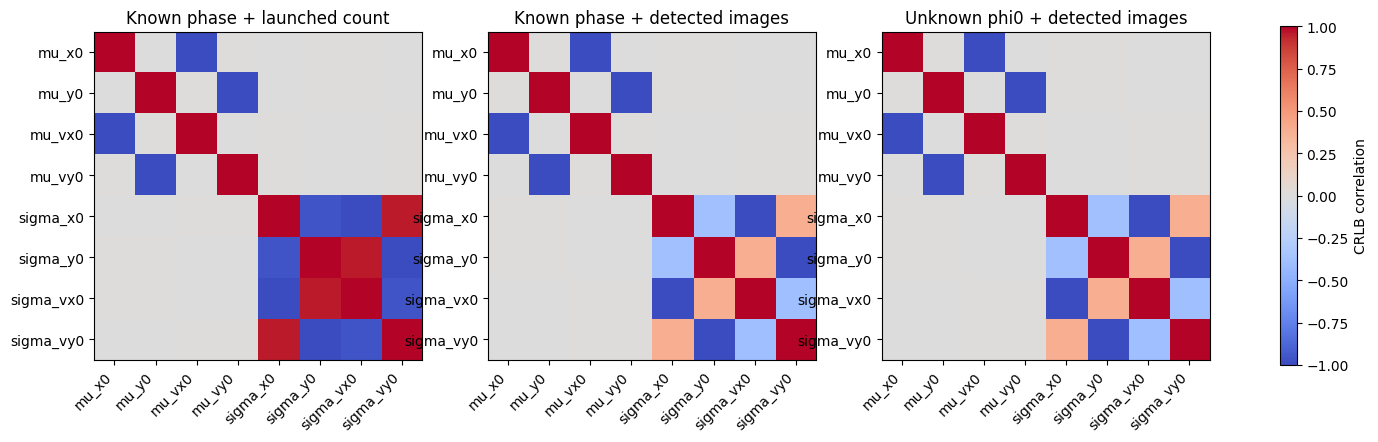

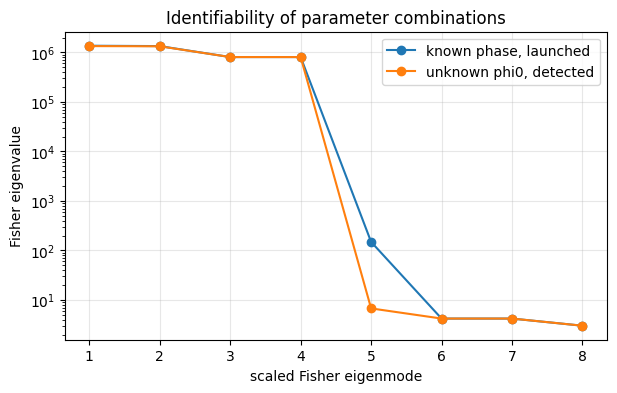

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, corr, title in zip(
    axs,
    [launched_result.correlation, conditional_result.correlation, conditional_phi_nuisance_correlation],
    ['Known phase + launched count', 'Known phase + detected images', 'Unknown phi0 + detected images'],
):
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
    ax.set_xticks(range(8), PARAMETER_NAMES, rotation=45, ha='right')
    ax.set_yticks(range(8), PARAMETER_NAMES)
    ax.set_title(title)
fig.colorbar(im, ax=axs, label='CRLB correlation', shrink=0.8)

plt.figure(figsize=(7, 4))
for label, eigenvalues in [
    ('known phase, launched', launched_result.eigenvalues_scaled[::-1]),
    ('unknown phi0, detected', conditional_phi_nuisance_eigenvalues[::-1]),
]:
    plt.semilogy(range(1, len(eigenvalues) + 1), np.maximum(eigenvalues, 1e-300), marker='o', label=label)
plt.xlabel('scaled Fisher eigenmode')
plt.ylabel('Fisher eigenvalue')
plt.title('Identifiability of parameter combinations')
plt.grid(alpha=0.3)
plt.legend()


## Optional: dependence on interferometer phase

A single-shot image can carry very different information at fringe maximum and mid-fringe. Enable this scan to see whether the selected or randomly sampled $\phi_0$ values leave particular initial conditions poorly constrained.

In [21]:
RUN_PHASE_SCAN = False

if RUN_PHASE_SCAN:
    phase_values = np.linspace(0, 2*np.pi, 13, endpoint=False)
    phase_precisions = []
    for phase in phase_values:
        phase_model = PSMAPConditionalImageModel.from_psmap(
            psmap, T_DET, phase, x_edges, y_edges, hermite_order=HERMITE_ORDER
        )
        result = phase_model.fisher_information(theta_nominal, N_ATOMS, parameter_scales)
        phase_precisions.append(result.standard_deviations * display_scales)
    phase_precisions = np.asarray(phase_precisions)

    fig, axs = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
    for index, ax in enumerate(axs.flat):
        ax.plot(phase_values, phase_precisions[:, index], marker='o')
        ax.set_title(PARAMETER_NAMES[index])
        ax.set_ylabel(f'CRLB [{units[index]}]')
        ax.set_xlabel('phi0 [rad]')
        ax.grid(alpha=0.3)
    fig.tight_layout()
else:
    print('Set RUN_PHASE_SCAN=True to calculate phase-dependent bounds.')


Set RUN_PHASE_SCAN=True to calculate phase-dependent bounds.


## Optional comparison with PCA/summary-feature regression

This cell trains the existing quadratic Ridge feature model and evaluates it on complete held-out runs. The dataset spans many cloud parameters and random common phases. The most faithful benchmark is therefore the random-phase ensemble summary above with `phi0` profiled as a nuisance parameter. If that scan is disabled, `conditional_phi_nuisance_std` is only the local unknown-phase CRLB at `PHI0`.

A feature-regression RMSE below the CRLB is not a violation: the regression is generally biased and learns the finite parameter distribution in the training set, whereas this CRLB is a local bound for unbiased estimation of one nominal cloud from binned images. The feature model also uses separately calculated final-position moments.


In [22]:
from sklearn.base import clone
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

artifact_dir = REPO / 'results' / '2d-shot-features'
pca_path = artifact_dir / '2d-shot-pcas.npz'

if (artifact_dir / 'shot_metadata.npz').exists() and pca_path.exists():
    metadata = np.load(artifact_dir / 'shot_metadata.npz')
    pca = np.load(pca_path)
    X = np.column_stack([metadata['summary_features'], pca['scores'][:, :5]])
    targets = {name: metadata[name if not name.startswith('sigma_') else name.replace('0', '')] for name in PARAMETER_NAMES}
    train, test = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42).split(X, groups=metadata['run_id']))
    feature_model = Pipeline([
        ('input_scaler', StandardScaler()),
        ('quadratic_features', PolynomialFeatures(2, include_bias=False)),
        ('quadratic_scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1e-2)),
    ])
    rows = []
    for index, (name, target) in enumerate(targets.items()):
        prediction = clone(feature_model).fit(X[train], target[train]).predict(X[test])
        rmse = np.sqrt(mean_squared_error(target[test], prediction))
        fisher_std = conditional_phi_nuisance_std[index]
        rows.append({'parameter': name, 'held_out_feature_RMSE': rmse * display_scales[index],
                     'unknown_phi0_full_image_CRLB': fisher_std * display_scales[index],
                     'RMSE_over_CRLB': rmse / fisher_std, 'unit': units[index]})
    display(pd.DataFrame(rows).set_index('parameter'))
else:
    print(f'Feature artifacts not found at {artifact_dir}; run the extraction/PCA pipeline first.')


,held_out_feature_RMSE,unknown_phi0_full_image_CRLB,RMSE_over_CRLB,unit
parameter,,,,
mu_x0,10.161041,4.710604,2.157057,um
mu_y0,9.372287,4.710604,1.989615,um
mu_vx0,2.253079,1.227336,1.835747,um/s
mu_vy0,2.044561,1.227336,1.665852,um/s
sigma_x0,10.321500,4.880292,2.114935,um
sigma_y0,9.897676,4.880292,2.028091,um
sigma_vx0,0.548183,0.317057,1.728971,um/s
sigma_vy0,0.544113,0.317057,1.716134,um/s


## Interpretation checklist

- A rank below eight means at least one combination of initial conditions is not locally identifiable from this measurement.
- Very large CRLB correlations expose degeneracies, such as final position constraining a combination of initial position and velocity.
- The known-phase full-image CRLB is an optimistic upper benchmark for PCA, phase-gradient, curvature, or moment-based estimators.
- The local unknown-`phi0` CRLB profiles over phase uncertainty for one selected phase value.
- For the random-`phi0` synthetic data, compare feature regression to the random-phase ensemble summary with unknown `phi0` profiled.
- Compare Gauss-Hermite orders (for example 8, 12, and 16) before quoting final values; the residual variation is numerical integration uncertainty.
- This benchmark still assumes the PSMAP, atom number model, and imaging response are known exactly. Additional experimental nuisance parameters would weaken the bound and should eventually be added to `theta`.
